El Nino Pacific case study; Cleaned notebook to support the report

In [4]:
# reusable processing scripts
import sys
sys.path.append(r'..\4. Reusable Processing Scripts')  # adjust to actual relative path

import numpy as np
import pandas as pd
from pathlib import Path

from maap_access import get_token, search_retry, download_granule
from biomass_io import (read_bands, parse_granule_id, corner_grid,
                         hhvv_phase, is_complete_granule)
from circular_stats import circular_stats, circ_smooth
from granule_cache import load_or_build_cache, extend_cache, load_granules

In [5]:
# loader cell
NINO_DIR = Path(r'C:\Users\Orlaith.Doyle\Nino')
ARCHIVE  = NINO_DIR / 'Nino-prods'
DATE     = '2026-06-30'
DEC      = 6            # display decimation
MIN_FRAMES = 3          # drop tracks with fewer frames than this

CACHE = NINO_DIR / f'layers_{DATE}.pkl'
ROOT  = ARCHIVE / DATE

layers, df = load_or_build_cache(ROOT, CACHE, decimation=DEC, min_frames=MIN_FRAMES)

keep = sorted({l['track'] for l in layers})
print(f'\n{len(layers)} frames across {len(keep)} tracks: {keep}')
print('\n=== per track ===')
print(df.groupby('track').agg(frames=('frame','size'), lon=('lon_c','mean'),
                              lat_lo=('lat_c','min'), lat_hi=('lat_c','max'),
                              mean_deg=('mean_deg','mean'),
                              coh=('coh','mean')).round(3).to_string())
allv = np.concatenate([l['phi'].ravel() for l in layers])
v = allv[np.isfinite(allv)]
zc = np.mean(np.exp(1j*v))
print(f'\nwhole day: mean {np.degrees(np.angle(zc)):+.3f}°, '
      f'|coh| {np.abs(zc):.4f}, n={v.size:,}')
print('\nlayers and df ready.')

loaded cache: 118 frames from layers_2026-06-30.pkl

118 frames across 9 tracks: [30, 31, 32, 33, 37, 38, 39, 40, 41]

=== per track ===
       frames      lon  lat_lo  lat_hi  mean_deg    coh
track                                                  
30          9  -96.331   -8.40    0.83     0.543  0.925
31         15 -120.143   -8.39    7.87     0.486  0.928
32         17 -144.449   -8.38   10.02     0.332  0.929
33         17 -169.001   -8.41   10.01     0.472  0.926
37         12 -101.182  -34.57   -0.31     1.005  0.928
38         10 -124.567   -8.94    0.90     0.893  0.926
39         17 -141.903   -8.94    9.40     0.841  0.926
40         17 -166.460   -8.94    9.45     0.782  0.926
41          4   90.190    0.02    3.49     0.478  0.931

whole day: mean +0.645°, |coh| 0.9268, n=102,580,428

layers and df ready.


In [6]:
# Loads SMOS + SMAP
import numpy as np
import netCDF4 as nc4
import copernicusmarine
from pathlib import Path

NINO_DIR = Path(r'C:\Users\Orlaith.Doyle\Nino')
REF_DIR  = NINO_DIR / 'salinity'
REF_DIR.mkdir(parents=True, exist_ok=True)
DATE = '2026-06-30'
BOX = dict(minimum_longitude=-180.0, maximum_longitude=-75.0,
           minimum_latitude=-14.0,   maximum_latitude=14.0)
# SMOS L2Q ascending and descending
VARS = ['Sea_Surface_Salinity', 'Sea_Surface_Salinity_Error',
        'Sea_Surface_Salinity_QC', 'Sea_Surface_Salinity_Rain_Corrected',
        'Mean_Acq_Time', 'X_Swath']
for suf, dsid in (('asc', 'cmems_obs-mob_glo_phy-sss_mynrt_smos-asc_P1D'),
                  ('des', 'cmems_obs-mob_glo_phy-sss_mynrt_smos-des_P1D')):
    f = REF_DIR / f'smos_{suf}_{DATE}.nc'
    if f.exists():
        print(f'SMOS {suf}: cached'); continue
    try:
        copernicusmarine.subset(dataset_id=dsid, variables=VARS, **BOX,
            start_datetime=f'{DATE}T00:00:00', end_datetime=f'{DATE}T23:59:59',
            output_directory=str(REF_DIR), output_filename=f.name)
        with nc4.Dataset(f) as ds:
            s = np.squeeze(np.ma.filled(
                ds.variables['Sea_Surface_Salinity'][:], np.nan)).astype(float)
        print(f'SMOS {suf}: {int(np.isfinite(s).sum())} valid cells')
    except Exception as e:
        print(f'SMOS {suf}: FAILED -- {str(e)[:90]}')

# SMAP L2B swath
import earthaccess
try:
    earthaccess.login(strategy='netrc')
except Exception:
    earthaccess.login(strategy='interactive', persist=True)

res = earthaccess.search_data(
    short_name='SMAP_JPL_L2B_SSS_CAP_V5',
    temporal=(f'{DATE}T00:00:00', f'{DATE}T23:59:59'),
    bounding_box=(-180.0, -14.0, -75.0, 14.0))
print(f'\nSMAP: {len(res)} granule(s) found; checking coverage')
best = None
for gi, g in enumerate(res):
    try:
        pth = earthaccess.download([g], str(REF_DIR / 'smap_tmp'))[0]
        with nc4.Dataset(pth) as ds:
            nm = {k.lower(): k for k in ds.variables}
            vk = next((nm[k] for k in ('smap_sss','sss_smap','sss') if k in nm), None)
            lak = next((nm[k] for k in ('lat','latitude') if k in nm), None)
            lok = next((nm[k] for k in ('lon','longitude') if k in nm), None)
            if not (vk and lak and lok):
                continue
            s  = np.ma.filled(ds.variables[vk][:],  np.nan).astype(float)
            la = np.ma.filled(ds.variables[lak][:], np.nan).astype(float)
            lo = np.ma.filled(ds.variables[lok][:], np.nan).astype(float)
        lo = np.where(lo > 180, lo - 360, lo)
        ok = ((la >= -14) & (la <= 14) & (lo >= -180) & (lo <= -75)
              & np.isfinite(s) & (s > 20) & (s < 40))
        n = int(ok.sum())
        if n > 200:
            print(f'  granule {gi}: {n} cells, '
                  f'{np.nanmin(s[ok]):.2f}-{np.nanmax(s[ok]):.2f} PSU')
            if best is None or n > best[0]:
                best = (n, s, la, lo)
    except Exception as e:
        print(f'  granule {gi}: {str(e)[:50]}')
if best:
    n, s, la, lo = best
    np.savez_compressed(REF_DIR / f'smap_l2_{DATE}.npz',
                        sss=s.astype(np.float32), lat=la.astype(np.float32),
                        lon=lo.astype(np.float32))
    print(f'-> saved smap_l2_{DATE}.npz ({n} cells)')
else:
    print('-> no SMAP granule with useful coverage')

SMOS asc: cached
SMOS des: cached

SMAP: 0 granule(s) found; checking coverage
-> no SMAP granule with useful coverage


In [7]:
import numpy as np, netCDF4 as nc4
from pathlib import Path
from datetime import datetime, timedelta

REF_DIR = Path(r'C:\Users\Orlaith.Doyle\Nino') / 'salinity'
DATE = '2026-06-30'

for suf in ('asc', 'des'):
    f = REF_DIR / f'smos_{suf}_{DATE}.nc'
    if not f.exists():
        continue
    with nc4.Dataset(f) as ds:
        s   = np.squeeze(np.ma.filled(ds.variables['Sea_Surface_Salinity'][:],
                                      np.nan)).astype(float)
        mat = np.squeeze(np.ma.filled(ds.variables['Mean_Acq_Time'][:],
                                      np.nan)).astype(float)
        la  = np.ma.filled(ds.variables['latitude'][:], np.nan).astype(float)
        lo  = np.ma.filled(ds.variables['longitude'][:], np.nan).astype(float)
    b = datetime(2000, 1, 1)
    ok = np.isfinite(mat)
    hrs = np.full(mat.shape, np.nan)
    hrs[ok] = [(b+timedelta(days=float(x))).hour
               + (b+timedelta(days=float(x))).minute/60 for x in mat[ok]]
    print(f'\nSMOS {suf}: {int(np.isfinite(s).sum())} cells, '
          f'{np.nanmin(s):.2f}-{np.nanmax(s):.2f} PSU')
    print(f'  acq time UTC {np.nanmin(hrs):.2f} to {np.nanmax(hrs):.2f} '
          f'(median {np.nanmedian(hrs):.2f})')
    # how acquisition time varies with longitude
    for l0 in range(-180, -75, 20):
        m = (lo[None, :] >= l0) & (lo[None, :] < l0+20) & np.isfinite(hrs)
        if m.any():
            print(f'    {l0} to {l0+20}°E: median {np.nanmedian(hrs[m]):.2f} h')

# Biomass acquisition times from the granule IDs
import re
ARCH = Path(r'C:\Users\Orlaith.Doyle\Nino') / 'Nino-prods' / DATE
tt = []
for g in ARCH.iterdir():
    if not g.is_dir():
        continue
    d = re.findall(r'(\d{8}T\d{6})', g.name)
    t = re.search(r'_(T\d{3})_', g.name)
    if d and t:
        dt = datetime.strptime(d[0], '%Y%m%dT%H%M%S')
        tt.append((t.group(1), dt.hour + dt.minute/60))
if tt:
    import pandas as pd
    bt = pd.DataFrame(tt, columns=['track', 'hour'])
    print('\nBiomass acquisition times (UTC):')
    print(bt.groupby('track')['hour'].agg(['min','max','mean']).round(2).to_string())


SMOS asc: 20017 cells, 28.31-39.98 PSU
  acq time UTC 11.03 to 17.83 (median 14.45)
    -180 to -160°E: median 17.75 h
    -160 to -140°E: median 16.10 h
    -140 to -120°E: median 14.43 h
    -120 to -100°E: median 12.77 h
    -100 to -80°E: median 12.72 h
    -80 to -60°E: median 11.12 h

SMOS des: 23702 cells, 29.07-40.39 PSU
  acq time UTC 0.18 to 23.67 (median 3.58)
    -180 to -160°E: median 5.25 h
    -160 to -140°E: median 3.60 h
    -140 to -120°E: median 1.97 h
    -120 to -100°E: median 1.88 h
    -100 to -80°E: median 0.30 h
    -80 to -60°E: median 23.55 h

Biomass acquisition times (UTC):
         min    max   mean
track                     
T030    0.57   0.60   0.58
T031    2.17   2.23   2.20
T032    3.78   3.87   3.83
T033    5.43   5.52   5.47
T037   11.22  12.83  12.66
T038   12.85  14.48  14.14
T039   14.48  16.12  15.25
T040   16.12  17.75  16.89
T041   17.75  17.77  17.76


phase stretch +0.65° ± 22.35°

T030 (-96°E): phase +0.55°, SSS 35.268, des, +19 min
T031 (-120°E): phase +0.49°, SSS 34.739, des, +17 min
T032 (-145°E): phase +0.36°, SSS 34.701, des, +15 min
T033 (-169°E): phase +0.47°, SSS 35.123, des, +13 min
T037 (-102°E): phase +1.02°, SSS 35.253, asc, -4 min
T038 (-125°E): phase +0.90°, SSS 34.712, asc, -15 min
T039 (-141°E): phase +0.83°, SSS 34.895, asc, -48 min
T040 (-166°E): phase +0.78°, SSS 34.805, asc, -50 min
T041 (+90°E): phase +0.48°, SSS 34.997, asc, +199 min


C:\Users\Orlaith.Doyle\AppData\Local\Temp\ipykernel_11640\2489723847.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.90, 0.94])


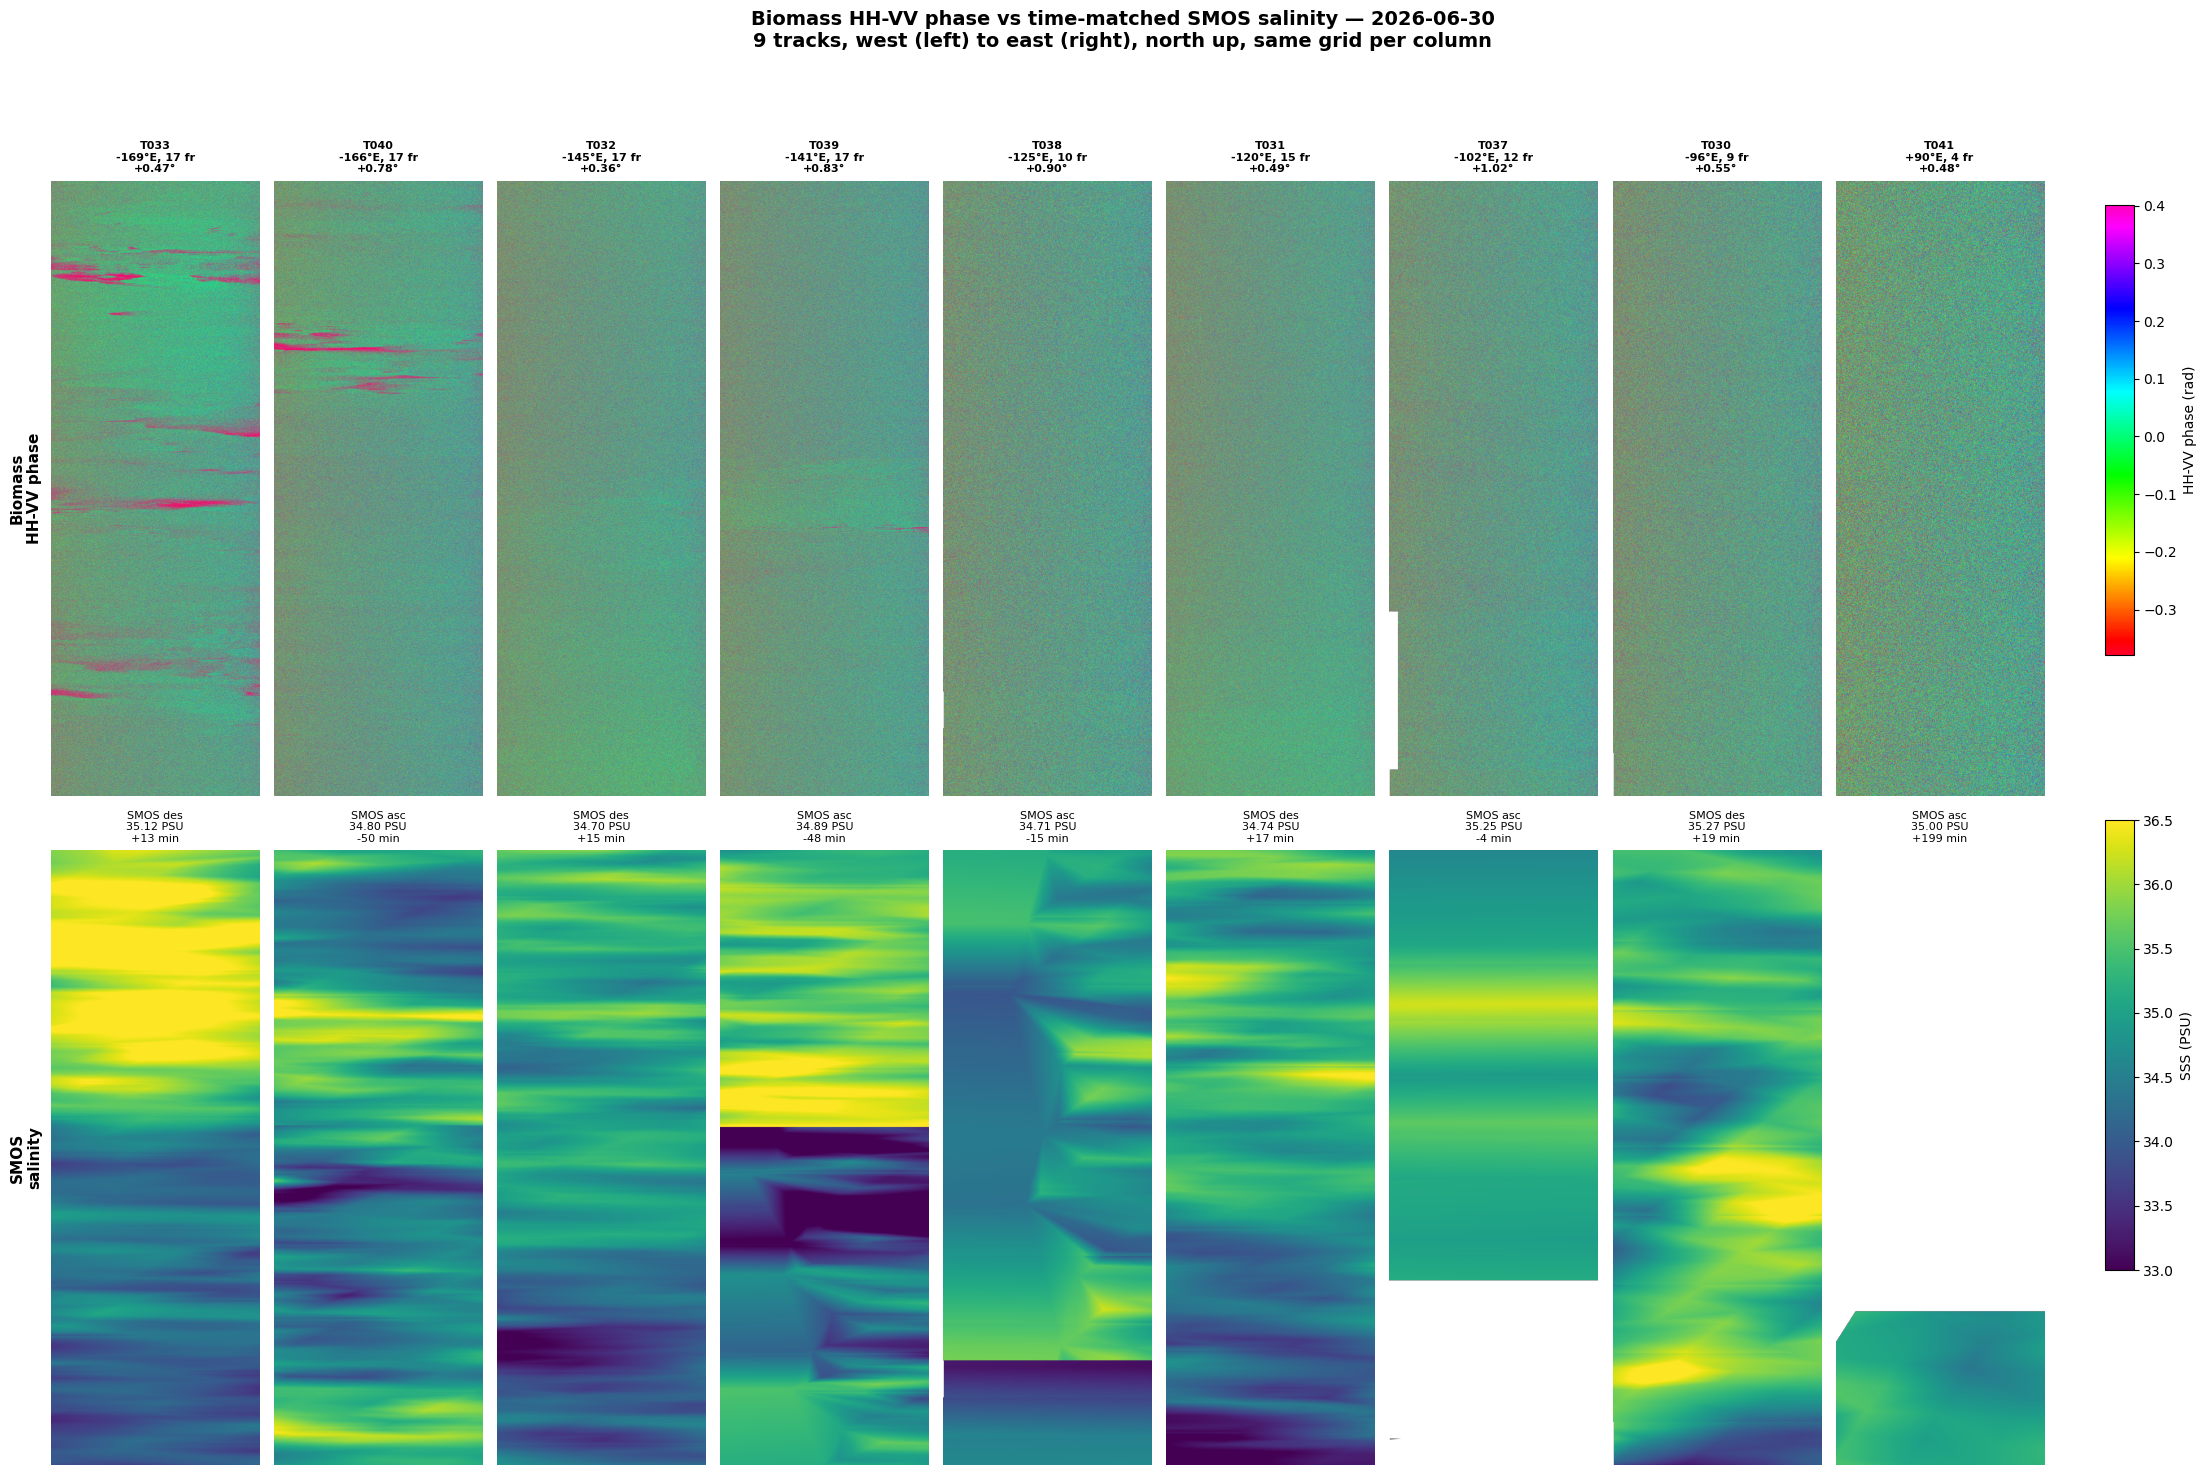


=== west to east ===
 track  lon_c  frames  phase_deg    coh  sss_mean smos_pass  offset_min
    33 -169.1      17      0.466 0.9264    35.123       des          13
    40 -166.0      17      0.779 0.9255    34.805       asc         -50
    32 -144.5      17      0.361 0.9284    34.701       des          15
    39 -141.5      17      0.831 0.9260    34.895       asc         -48
    38 -125.3      10      0.899 0.9260    34.712       asc         -15
    31 -120.2      15      0.494 0.9278    34.739       des          17
    37 -102.2      12      1.018 0.9275    35.253       asc          -4
    30  -96.4       9      0.551 0.9243    35.268       des          19
    41   90.2       4      0.478 0.9310    34.997       asc         199

track phase vs SSS: Pearson +0.136, Spearman +0.200

Saved: C:\Users\Orlaith.Doyle\Nino\phase_vs_salinity\grid_phase_vs_smos_2026-06-30.png


In [8]:
%matplotlib inline
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import netCDF4 as nc4
from pathlib import Path
from datetime import datetime, timedelta
from scipy.interpolate import griddata

NINO_DIR = Path(r'C:\Users\Orlaith.Doyle\Nino')
REF_DIR  = NINO_DIR / 'salinity'
ARCH     = NINO_DIR / 'Nino-prods'
SAVE_DIR = NINO_DIR / 'phase_vs_salinity'
SAVE_DIR.mkdir(parents=True, exist_ok=True)
DATE = '2026-06-30'
SSS_CMAP, SSS_VMIN, SSS_VMAX = 'viridis', 33.0, 36.5
FLIP_VERTICAL, FLIP_HORIZONTAL = True, True
PAD = 4.0

if 'layers' not in dir() or not layers:
    raise RuntimeError('layers not in memory')
keep = sorted({l['track'] for l in layers})
hdiff = lambda a, b: (a - b + 12) % 24 - 12

# Biomass acquisition hour per track
bio_hour = {}
for g in (ARCH / DATE).iterdir():
    if not g.is_dir():
        continue
    d = re.findall(r'(\d{8}T\d{6})', g.name)
    t = re.search(r'_(T\d{3})_', g.name)
    if d and t:
        dt = datetime.strptime(d[0], '%Y%m%dT%H%M%S')
        bio_hour.setdefault(int(t.group(1)[1:]), []).append(dt.hour + dt.minute/60)
bio_hour = {k: float(np.mean(v)) for k, v in bio_hour.items()}

# both SMOS passes
smos = {}
for suf in ('asc', 'des'):
    f = REF_DIR / f'smos_{suf}_{DATE}.nc'
    if not f.exists():
        continue
    with nc4.Dataset(f) as ds:
        key = ('Sea_Surface_Salinity_Rain_Corrected'
               if 'Sea_Surface_Salinity_Rain_Corrected' in ds.variables
               else 'Sea_Surface_Salinity')
        sss = np.squeeze(np.ma.filled(ds.variables[key][:], np.nan)).astype(float)
        mat = np.squeeze(np.ma.filled(ds.variables['Mean_Acq_Time'][:],
                                      np.nan)).astype(float)
        la = np.ma.filled(ds.variables['latitude'][:], np.nan).astype(float)
        lo = np.ma.filled(ds.variables['longitude'][:], np.nan).astype(float)
    b = datetime(2000, 1, 1)
    hrs = np.full(mat.shape, np.nan); mm = np.isfinite(mat)
    hrs[mm] = [(b+timedelta(days=float(x))).hour
               + (b+timedelta(days=float(x))).minute/60 for x in mat[mm]]
    smos[suf] = dict(sss=np.where((sss > 20) & (sss < 42), sss, np.nan),
                     hrs=hrs, lat=la, lon=lo)

# shared phase stretch
allv = np.concatenate([l['phi'].ravel() for l in layers])
v = allv[np.isfinite(allv)]
zc = np.mean(np.exp(1j*v)); R = float(np.abs(zc))
cmean = float(np.angle(zc))
spread = float(np.sqrt(max(0.0, -2.0*np.log(max(R, 1e-12)))))
vmin, vmax = cmean-spread, cmean+spread
print(f'phase stretch {np.degrees(cmean):+.2f}° ± {np.degrees(spread):.2f}°\n')

#  build both stacks per track 
cols, rows = [], []
for t in keep:
    sub = sorted([l for l in layers if l['track'] == t], key=lambda x: x['frame'])
    alon = np.concatenate([s['lon'].ravel() for s in sub])
    alat = np.concatenate([s['lat'].ravel() for s in sub])
    lo0, lo1 = float(np.nanmin(alon)), float(np.nanmax(alon))
    la0, la1 = float(np.nanmin(alat)), float(np.nanmax(alat))
    lon_c = float(np.nanmean(alon))
    bh = bio_hour.get(t, np.nan)

    best = None
    for suf, S in smos.items():
        m = ((S['lat'][:,None] >= la0-PAD) & (S['lat'][:,None] <= la1+PAD)
             & (S['lon'][None,:] >= lo0-PAD) & (S['lon'][None,:] <= lo1+PAD)
             & np.isfinite(S['sss']) & np.isfinite(S['hrs']))
        if not m.any():
            continue
        med = float(np.nanmedian(S['hrs'][m]))
        off = abs(hdiff(bh, med)) if np.isfinite(bh) else 99
        if best is None or off < best[0]:
            best = (off, suf, med)
    if best is None:
        print(f'T{t:03d}: no SMOS'); continue
    off_h, suf, smos_h = best
    S = smos[suf]

    LA, LO = np.meshgrid(S['lat'], S['lon'], indexing='ij')
    ok = np.isfinite(S['sss'])
    pts = np.column_stack([LO[ok].ravel(), LA[ok].ravel()])
    vals = S['sss'][ok].ravel()
    sss_frames = [griddata(pts, vals, (s['lon'], s['lat']), method='linear')
                  for s in sub]

    def build(arrs):
        w = max(a.shape[1] for a in arrs)
        return np.vstack([np.pad(a, ((0,0),(0, w-a.shape[1])),
                                 constant_values=np.nan) for a in arrs])
    ph = build([s['phi'] for s in sub])
    ss = build(sss_frames)
    if FLIP_VERTICAL:
        ph, ss = np.flipud(ph), np.flipud(ss)
    if FLIP_HORIZONTAL:
        ph, ss = np.fliplr(ph), np.fliplr(ss)

    pv = ph[np.isfinite(ph)]
    pz = np.mean(np.exp(1j*pv))
    sv = ss[np.isfinite(ss)]
    cols.append(dict(track=t, lon_c=lon_c, phase=ph, sss=ss,
                     lat_lo=la0, lat_hi=la1, frames=len(sub),
                     pmean=float(np.degrees(np.angle(pz))),
                     coh=float(np.abs(pz)),
                     smean=float(np.nanmean(sv)) if sv.size else np.nan,
                     suf=suf, off=hdiff(bh, smos_h)*60))
    rows.append(dict(track=t, lon_c=round(lon_c,1), frames=len(sub),
                     phase_deg=round(float(np.degrees(np.angle(pz))),3),
                     coh=round(float(np.abs(pz)),4),
                     sss_mean=round(float(np.nanmean(sv)),3) if sv.size else np.nan,
                     smos_pass=suf, offset_min=round(hdiff(bh, smos_h)*60)))
    print(f'T{t:03d} ({lon_c:+.0f}°E): phase {rows[-1]["phase_deg"]:+.2f}°, '
          f'SSS {rows[-1]["sss_mean"]}, {suf}, {rows[-1]["offset_min"]:+d} min')

cols.sort(key=lambda c: c['lon_c'])          # west to east
n = len(cols)
fig, axes = plt.subplots(2, n, figsize=(2.6*n, 15))
axes = np.atleast_2d(axes)

for k, c in enumerate(cols):
    a0 = axes[0, k]
    im0 = a0.imshow(c['phase'], cmap='gist_rainbow', vmin=vmin, vmax=vmax,
                    aspect='auto')
    a0.set_title(f"T{c['track']:03d}\n{c['lon_c']:+.0f}°E, {c['frames']} fr\n"
                 f"{c['pmean']:+.2f}°", fontsize=8, fontweight='bold')
    a0.axis('off')

    a1 = axes[1, k]
    im1 = a1.imshow(c['sss'], cmap=SSS_CMAP, vmin=SSS_VMIN, vmax=SSS_VMAX,
                    aspect='auto')
    a1.set_title(f"SMOS {c['suf']}\n{c['smean']:.2f} PSU\n"
                 f"{c['off']:+.0f} min", fontsize=8)
    a1.axis('off')

axes[0, 0].text(-0.12, 0.5, 'Biomass\nHH-VV phase', transform=axes[0,0].transAxes,
                rotation=90, va='center', ha='center', fontsize=11,
                fontweight='bold')
axes[1, 0].text(-0.12, 0.5, 'SMOS\nsalinity', transform=axes[1,0].transAxes,
                rotation=90, va='center', ha='center', fontsize=11,
                fontweight='bold')

cax0 = fig.add_axes([0.92, 0.55, 0.012, 0.30])
fig.colorbar(im0, cax=cax0, label='HH-VV phase (rad)')
cax1 = fig.add_axes([0.92, 0.14, 0.012, 0.30])
fig.colorbar(im1, cax=cax1, label='SSS (PSU)')

fig.suptitle(f'Biomass HH-VV phase vs time-matched SMOS salinity — {DATE}\n'
             f'{n} tracks, west (left) to east (right), '
             f'north up, same grid per column',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0.02, 0, 0.90, 0.94])
out = SAVE_DIR / f'grid_phase_vs_smos_{DATE}.png'
plt.savefig(out, dpi=190, bbox_inches='tight')
plt.show()

summ = pd.DataFrame(rows).sort_values('lon_c')
summ.to_csv(SAVE_DIR / f'grid_summary_{DATE}.csv', index=False)
print('\n West to East')
print(summ.to_string(index=False))
rk = lambda a: np.argsort(np.argsort(a))
s2 = summ.dropna(subset=['sss_mean'])
if len(s2) > 2:
    print(f'\ntrack phase vs SSS: '
          f'Pearson {np.corrcoef(s2["sss_mean"], s2["phase_deg"])[0,1]:+.3f}, '
          f'Spearman {np.corrcoef(rk(s2["sss_mean"]), rk(s2["phase_deg"]))[0,1]:+.3f}')
print(f'\nSaved: {out}')

night tracks: [np.int64(30), np.int64(31), np.int64(32), np.int64(33)]
split at 0.58°: 24 dark-red, 34 light-red
hull exclusions: set()
96 corner points from hull-eligible frames
hull: lon -171.8 to -94.5, lat -9.3 to +2.9


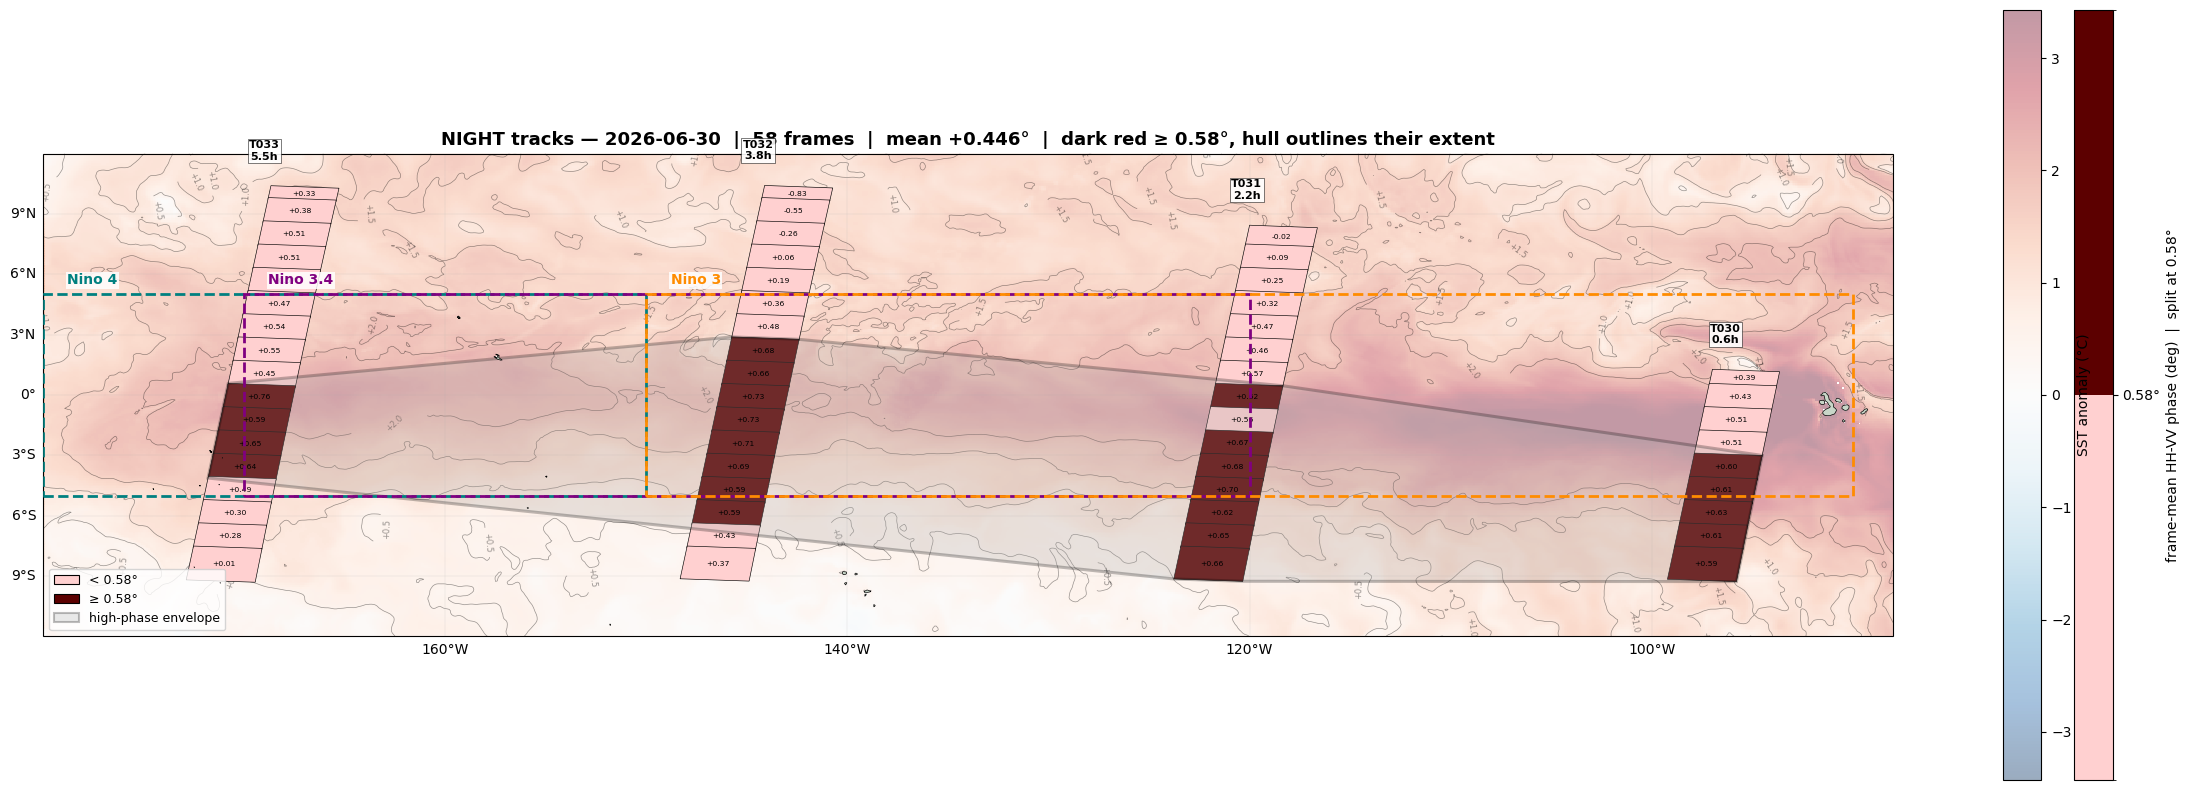

Saved: C:\Users\Orlaith.Doyle\Nino\phase_figures\night_hull_2026-06-30.png


In [17]:
# Mirrors the day tracks above, filtered to night-acquired tracks instead.
%matplotlib inline
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
from scipy.spatial import ConvexHull
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import netCDF4 as nc4
from pathlib import Path
from datetime import datetime

NINO_DIR = Path(r'C:\Users\Orlaith.Doyle\Nino')
SST_DIR  = NINO_DIR / 'sst'
ARCH     = NINO_DIR / 'Nino-prods'
SAVE_DIR = NINO_DIR / 'phase_figures'
SAVE_DIR.mkdir(parents=True, exist_ok=True)
DATE = '2026-06-30'

WIDEN        = 6.0
BG_ALPHA     = 0.40
EXTENT       = [-180, -88, -12, 12]
SPLIT        = 0.58
TIER_COLOURS = ['#ffd0d0', '#5c0000']
LABEL        = True
HULL_EXCLUDE = set()   # no exclusions for the night set

cmap3 = ListedColormap(TIER_COLOURS)
norm3 = BoundaryNorm([-1e3, SPLIT, 1e3], cmap3.N)

if 'layers' not in dir() or not layers:
    raise RuntimeError('layers not in memory')

def parse_hour(gid):
    d = re.findall(r'(\d{8}T\d{6})', gid)
    if d:
        dt = datetime.strptime(d[0], '%Y%m%dT%H%M%S')
        return dt.hour + dt.minute/60
    return np.nan

bio_hour = {}
for g in (ARCH / DATE).iterdir():
    if not g.is_dir():
        continue
    t = re.search(r'_(T\d{3})_', g.name)
    if t:
        bio_hour.setdefault(int(t.group(1)[1:]), []).append(parse_hour(g.name))
bio_hour = {k: float(np.mean(v)) for k, v in bio_hour.items()}

rows = []
for l in layers:
    v = l['phi'][np.isfinite(l['phi'])]
    if v.size == 0:
        continue
    z = np.mean(np.exp(1j*v))
    h = bio_hour.get(l['track'], np.nan)
    rows.append(dict(track=l['track'], frame=l['frame'],
                     mean_deg=float(np.degrees(np.angle(z))),
                     group='night' if h < 9 else 'day', hour=h))
fm = pd.DataFrame(rows)
night = fm[fm['group'] == 'night']
hi_frames = night[night['mean_deg'] >= SPLIT]
print(f'night tracks: {sorted(night["track"].unique())}')
print(f'split at {SPLIT}°: {len(hi_frames)} dark-red, '
      f'{len(night)-len(hi_frames)} light-red')
print(f'hull exclusions: {HULL_EXCLUDE}')

NINO = {'Nino 4': (-180.,-5.,-150.,5.), 'Nino 3.4': (-170.,-5.,-120.,5.),
        'Nino 3': (-150.,-5.,-90.,5.)}
NCOL = {'Nino 4':'teal','Nino 3.4':'purple','Nino 3':'darkorange'}
land = cfeature.NaturalEarthFeature('physical','land','50m',
                                    edgecolor='black', facecolor='#c8d6c8')

fig = plt.figure(figsize=(22, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

bg_mesh = None
f = SST_DIR / f'sst_anom_{DATE}.nc'
if f.exists():
    with nc4.Dataset(f) as ds:
        vk = next(k for k in ds.variables if 'anomaly' in k.lower())
        anom = np.squeeze(np.ma.filled(ds.variables[vk][:], np.nan)).astype(float)
        bla = np.ma.filled(ds.variables['latitude'][:], np.nan).astype(float)
        blo = np.ma.filled(ds.variables['longitude'][:], np.nan).astype(float)
    lim = max(1.0, float(np.nanpercentile(np.abs(anom), 98)))
    bg_mesh = ax.pcolormesh(blo, bla, anom, cmap='RdBu_r', vmin=-lim, vmax=lim,
                            shading='auto', alpha=BG_ALPHA,
                            transform=ccrs.PlateCarree(), zorder=1)
    cs = ax.contour(blo, bla, anom, levels=[0.5,1.0,1.5,2.0], colors='k',
                    linewidths=0.5, alpha=0.4, transform=ccrs.PlateCarree(), zorder=2)
    ax.clabel(cs, fontsize=6, fmt='%+.1f')

# frame polygons — all drawn including excluded ones
for l in layers:
    r = night[(night['track'] == l['track']) & (night['frame'] == l['frame'])]
    if r.empty:
        continue
    val = float(r.iloc[0]['mean_deg'])
    lon, lat = l['lon'], l['lat']
    lon_mid = np.nanmean(lon, axis=1, keepdims=True)
    lon_w = lon_mid + (lon - lon_mid) * WIDEN
    poly = np.vstack([
        np.column_stack([lon_w[0,:],     lat[0,:]]),
        np.column_stack([lon_w[:,-1],    lat[:,-1]]),
        np.column_stack([lon_w[-1,::-1], lat[-1,::-1]]),
        np.column_stack([lon_w[::-1,0],  lat[::-1,0]])])
    ax.add_patch(mpatches.Polygon(poly, closed=True,
                 facecolor=cmap3(norm3(val)), edgecolor='black', lw=0.45,
                 zorder=5, transform=ccrs.PlateCarree()))
    if LABEL:
        ax.text(float(np.nanmean(lon_w)), float(np.nanmean(lat)),
                f'{val:+.2f}', fontsize=5.5, ha='center', va='center',
                zorder=7, transform=ccrs.PlateCarree())

# hull — excluded frames skipped
hull_pts = []
for l in layers:
    r = night[(night['track'] == l['track']) & (night['frame'] == l['frame'])]
    if r.empty or float(r.iloc[0]['mean_deg']) < SPLIT:
        continue
    if (l['track'], l['frame']) in HULL_EXCLUDE:
        continue
    lon, lat = l['lon'], l['lat']
    lon_mid = np.nanmean(lon, axis=1, keepdims=True)
    lon_w = lon_mid + (lon - lon_mid) * WIDEN
    for lo_c, la_c in [(lon_w[0, 0],   lat[0, 0]),
                       (lon_w[0, -1],  lat[0, -1]),
                       (lon_w[-1, 0],  lat[-1, 0]),
                       (lon_w[-1, -1], lat[-1, -1])]:
        if np.isfinite(lo_c) and np.isfinite(la_c):
            hull_pts.append([lo_c, la_c])
print(f'{len(hull_pts)} corner points from hull-eligible frames')
if len(hull_pts) >= 3:
    pts = np.array(hull_pts)
    hull = ConvexHull(pts)
    poly = pts[hull.vertices]
    ax.add_patch(mpatches.Polygon(poly, closed=True,
                 facecolor='#aaaaaa', alpha=0.25,
                 edgecolor='black', lw=2.2, zorder=6,
                 transform=ccrs.PlateCarree()))
    print(f'hull: lon {pts[:,0].min():+.1f} to {pts[:,0].max():+.1f}, '
          f'lat {pts[:,1].min():+.1f} to {pts[:,1].max():+.1f}')
else:
    print('not enough points for hull')

for nme, (a, b, c, d) in NINO.items():
    ax.add_patch(mpatches.Rectangle((a, b), c-a, d-b, facecolor='none',
                 edgecolor=NCOL[nme], lw=2.0, ls='--', zorder=8,
                 transform=ccrs.PlateCarree()))
    ax.text(a+1.2, d+0.5, nme, color=NCOL[nme], fontsize=10, fontweight='bold',
            zorder=9, transform=ccrs.PlateCarree(),
            bbox=dict(fc='white', ec='none', alpha=0.85, pad=1.2))

night_tracks = sorted(night['track'].unique())
for t in night_tracks:
    lsub = [l for l in layers if l['track'] == t]
    if not lsub:
        continue
    lonc = float(np.nanmean([np.nanmean(l['lon']) for l in lsub]))
    latc = float(max(np.nanmax(l['lat']) for l in lsub))
    ax.text(lonc, latc+1.3, f'T{t:03d}\n{bio_hour.get(t,0):.1f}h',
            fontsize=8, ha='center', fontweight='bold', zorder=10,
            transform=ccrs.PlateCarree(),
            bbox=dict(fc='white', ec='black', lw=0.4, alpha=0.9, pad=1.0))

ax.add_feature(land, zorder=6, lw=0.5)
gl = ax.gridlines(draw_labels=True, lw=0.3, alpha=0.4)
gl.top_labels = gl.right_labels = False
ax.set_extent(EXTENT, crs=ccrs.PlateCarree())

sm = ScalarMappable(norm=norm3, cmap=cmap3); sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.020, pad=0.015, ticks=[SPLIT])
cb.set_label(f'frame-mean HH-VV phase (deg)  |  split at {SPLIT}°')
cb.ax.set_yticklabels([f'{SPLIT}°'])
if bg_mesh is not None:
    cb2 = fig.colorbar(bg_mesh, ax=ax, fraction=0.020, pad=0.055)
    cb2.set_label('SST anomaly (°C)')

leg = [mpatches.Patch(fc='#ffd0d0', ec='black', lw=0.8, label=f'< {SPLIT}°'),
       mpatches.Patch(fc='#5c0000', ec='black', lw=0.8, label=f'≥ {SPLIT}°'),
       mpatches.Patch(fc='#aaaaaa', alpha=0.25, ec='black', lw=1.5,
                      label='high-phase envelope')]
ax.legend(handles=leg, loc='lower left', fontsize=9)
ax.set_title(f'NIGHT tracks — {DATE}  |  {len(night)} frames  |  '
             f'mean {night["mean_deg"].mean():+.3f}°  |  '
             f'dark red ≥ {SPLIT}°, hull outlines their extent',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out = SAVE_DIR / f'night_hull_{DATE}.png'
plt.savefig(out, dpi=220, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')